In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


/Users/vilasini/Documents/WALE/src/wale/FilterFunctions.py:129: SyntaxWarning: invalid escape sequence '\('
  eta (np.ndarray or float): Dimensionless argument \( \hat{u} \).


Skipping invalid cosmology 8
Skipping invalid cosmology 20
Skipping invalid cosmology 47
Skipping invalid cosmology 50
Skipping invalid cosmology 61
Skipping invalid cosmology 62
Skipping invalid cosmology 94
Skipping invalid cosmology 104
Skipping invalid cosmology 106
Skipping invalid cosmology 111
Skipping invalid cosmology 113
Skipping invalid cosmology 133
Skipping invalid cosmology 143
Skipping invalid cosmology 144
Skipping invalid cosmology 145
Skipping invalid cosmology 164
Skipping invalid cosmology 166
Skipping invalid cosmology 177
Skipping invalid cosmology 179
Skipping invalid cosmology 182


(-0.001, 0.3)

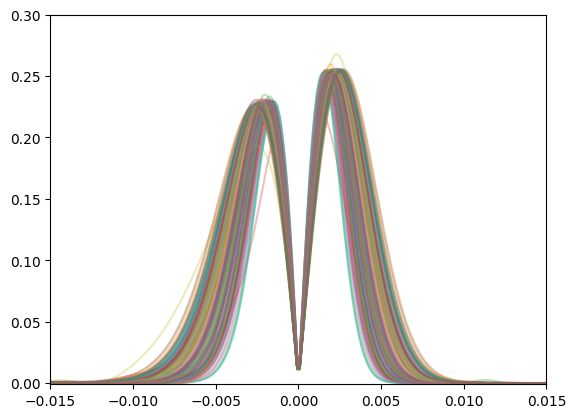

In [3]:
datafile = np.load("../data/cosmo_parallel_results_bin4_theta30.npz", allow_pickle=True)

data = datafile["results"]

results = data.tolist()             # convert to list of python dicts

cosmo_id = np.array([r["cosmo_id"] for r in results])

Om      = np.array([r["params"]["Om"]      for r in results])
sigma8  = np.array([r["params"]["sigma8"]  for r in results])
w       = np.array([r["params"]["w"]       for r in results])
h       = np.array([r["params"]["h"]       for r in results])
ns      = np.array([r["params"]["ns"]      for r in results])
Ob      = np.array([r["params"]["Ob"]      for r in results])
Oc      = np.array([r["params"]["Oc"]      for r in results])
wa      = np.array([r["params"]["wa"]      for r in results])


kappa_fix = np.array([r["kappa_fix"] for r in results], dtype=object)
snr_fix   = np.array([r["snr_fix"]   for r in results], dtype=object)


theory_l1_kappa_fix = np.array([r["theory_l1_kappa_fix"] for r in results], dtype=object)
theory_l1_snr_fix   = np.array([r["theory_l1_snr_fix"]   for r in results], dtype=object)
pred_stats          = np.array([r["pred_stats"]          for r in results], dtype=object)

cg_l1_kappa_mean = np.array([r["cg_l1_kappa_mean"] for r in results])
cg_l1_snr_mean   = np.array([r["cg_l1_snr_mean"]   for r in results])

cg_variance_mean = np.array([r["cg_variance_mean"] for r in results])
cg_variance_std  = np.array([r["cg_variance_std"]  for r in results])

cg_l1_kappa_std = np.array([r["cg_l1_kappa_std"] for r in results])
cg_l1_snr_std   = np.array([r["cg_l1_snr_std"]   for r in results])

cg_l1_kappa_realizations = np.array(
    [r["cg_l1_kappa_realizations"] for r in results], dtype=object
)

cg_l1_snr_realizations = np.array(
    [r["cg_l1_snr_realizations"] for r in results], dtype=object
)

for i in range(len(results)):
    if np.any(theory_l1_snr_fix[i] <-1e-3):
        print(f"Skipping invalid cosmology {i}")
        continue
    plt.plot(kappa_fix[i], theory_l1_kappa_fix[i], alpha=0.3)

plt.xlim(-0.015,0.015)
plt.ylim(-0.001,0.3)

In [18]:
datafile = np.load("../data/cosmo_parallel_results_bin4_Fiducial_theta30.npz", allow_pickle=True)

data_fiducial = datafile["results"]

results_fiducial = data_fiducial.tolist()             # convert to list of python dicts

cosmo_id = np.array([r["cosmo_id"] for r in results_fiducial])
#add _fiducial to variable names
Om_fiducial      = np.array([r["params"]["Om"]      for r in results_fiducial])
sigma8_fiducial  = np.array([r["params"]["sigma8"]  for r in results_fiducial])
w_fiducial       = np.array([r["params"]["w"]       for r in results_fiducial])
h_fiducial       = np.array([r["params"]["h"]       for r in results_fiducial])
ns_fiducial      = np.array([r["params"]["ns"]      for r in results_fiducial])
Ob_fiducial      = np.array([r["params"]["Ob"]      for r in results_fiducial])
Oc_fiducial      = np.array([r["params"]["Oc"]      for r in results_fiducial])
wa_fiducial      = np.array([r["params"]["wa"]      for r in results_fiducial])


kappa_fix_fiducial = np.array([r["kappa_fix"] for r in results_fiducial], dtype=object)
snr_fix_fiducial   = np.array([r["snr_fix"]   for r in results_fiducial], dtype=object)

theory_l1_kappa_fix_fiducial = np.array([r["theory_l1_kappa_fix"] for r in results_fiducial], dtype=object)
theory_l1_snr_fix_fiducial   = np.array([r["theory_l1_snr_fix"]   for r in results_fiducial], dtype=object)
pred_stats_fiducial         = np.array([r["pred_stats"]          for r in results_fiducial], dtype=object)

cg_l1_kappa_mean_fiducial = np.array([r["cg_l1_kappa_mean"] for r in results_fiducial])
cg_l1_snr_mean_fiducial   = np.array([r["cg_l1_snr_mean"]   for r in results_fiducial])

cg_variance_mean_fiducial = np.array([r["cg_variance_mean"] for r in results_fiducial])
cg_variance_std_fiducial  = np.array([r["cg_variance_std"]  for r in results_fiducial])

cg_l1_kappa_std_fiducial = np.array([r["cg_l1_kappa_std"] for r in results_fiducial])
cg_l1_snr_std_fiducial   = np.array([r["cg_l1_snr_std"]   for r in results_fiducial])
cg_l1_kappa_realizations_fiducial = np.array(
    [r["cg_l1_kappa_realizations"] for r in results_fiducial], dtype=object
)

cg_l1_snr_realizations_fiducial = np.array(
    [r["cg_l1_snr_realizations"] for r in results_fiducial], dtype=object
)



Skipped 30 invalid cosmologies


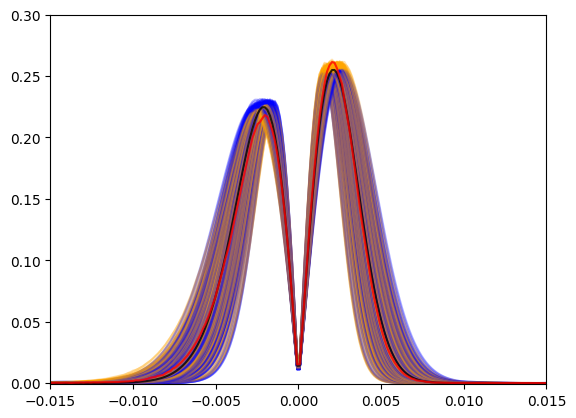

In [19]:
counter = 0
for i in range(len(results)):
    if np.any(theory_l1_kappa_fix[i] <-1e-3):
        # print(f"Skipping invalid cosmology {i}")
        counter += 1
        continue
    plt.plot(kappa_fix[i], theory_l1_kappa_fix[i], alpha=0.3, color='blue')
    plt.plot(kappa_fix[i], cg_l1_kappa_mean[i], alpha=0.3, color='orange')

plt.plot(kappa_fix_fiducial[0], theory_l1_kappa_fix_fiducial[0], alpha=0.8, color='black', label='Fiducial')
plt.plot(kappa_fix_fiducial[0], cg_l1_kappa_mean_fiducial[0], alpha=0.8, color='red', label='Fiducial Mean')
plt.xlim(-0.015,0.015)
plt.ylim(-0.001,0.3)

print(f"Skipped {counter} invalid cosmologies")